In [1]:
import pandas as pd
import decode
import torch
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from wip_util import smap_csv_to_emitters, get_np_points
import seaborn as sns

c:\Users\bnort\miniconda3\envs\decode_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
decode_csv_name_drift_correct = r'D:\Janelia_slm_data\processed\Janelia PALM RUN2\emitters_100_400_filtered_200_200_500_driftcorrect.csv'
emitters = smap_csv_to_emitters(decode_csv_name_drift_correct, 1, show_info=False)

C:\Users\bnort\AppData\Local\Temp\ipykernel_3948\3538920061.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
C:\Users\bnort\AppData\Local\Temp\ipykernel_3948\3538920061.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(emitters.xyz_sig_nm[::sub_

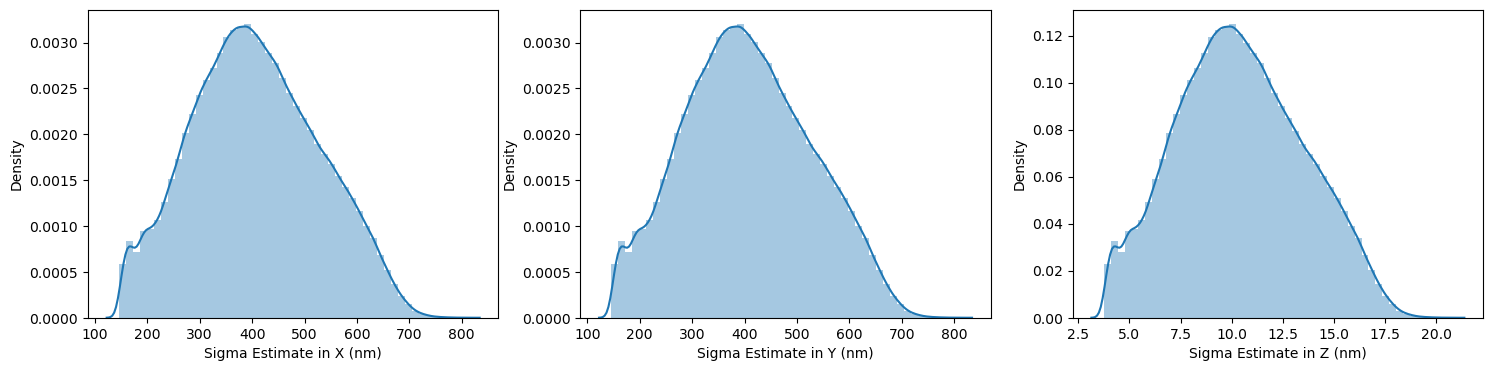

In [10]:
sub_sample = 25

plt.figure(figsize=(18,4))
plt.subplot(131)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 0].numpy())
plt.xlabel('Sigma Estimate in X (nm)')

plt.subplot(132)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 1].numpy())
plt.xlabel('Sigma Estimate in Y (nm)')

plt.subplot(133)
sns.distplot(emitters.xyz_sig_nm[::sub_sample, 2].numpy())
plt.xlabel('Sigma Estimate in Z (nm)')

plt.show()

In [11]:
print(emitters)
sigma_x_high_threshold = 400
sigma_y_high_threshold = 400
sigma_z_high_threshold = 10
prob_threshold = 0.5
coord_limit=((500,700),(100,200))
coord_limit=((0,500),(0,700))

print("0,1", coord_limit[0][0], coord_limit[0][1])

emitters_filtered = emitters[
    (emitters.xyz_sig_nm[:, 0] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 1] <= sigma_x_high_threshold)
    * (emitters.xyz_sig_nm[:, 2] <= sigma_z_high_threshold)
    * (emitters.prob >= prob_threshold)
    ]

print(emitters_filtered)



EmitterSet
::num emitters: 22545989
::xy unit: px
::px size: tensor([130., 130.])
::frame range: -1 - 74998
::spanned volume: [-3.405532e+00  1.788139e-07 -1.141419e+03] - [ 799.7149  801.2978 1158.095 ]
0,1 0 500
EmitterSet
::num emitters: 10507936
::xy unit: px
::px size: tensor([130., 130.])
::frame range: -1 - 74998
::spanned volume: [-3.405532e+00  1.788139e-07 -1.141419e+03] - [ 799.6227  801.2971 1158.095 ]


In [12]:
def render_emitters(emitters):

    fig, axs = plt.subplots(2, 2, figsize=(24, 12), sharex='col',
                            gridspec_kw={'height_ratios': [1, 1200 / 20000]})

    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-1000, 1000], colextent=[-1000, 1000], plot_axis=(0, 1),
                            contrast=15.25).render(emitters, emitters.xyz_nm[:, 2], ax=axs[0, 0])
    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], plot_axis=(0, 2)).render(emitters, ax=axs[1, 0])

    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 1),
                            contrast=1.25).render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[0, 1])

    decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=50,
                            zextent=[-600, 600], colextent=[0, 75], plot_axis=(0, 2)).\
        render(emitters, emitters.xyz_sig_weighted_tot_nm, ax=axs[1, 1])

    #plt.savefig(os.path.join(fig_path, rf'fitting\rendered.png'), dpi=300, bbox_inches='tight')
    #plt.show()

    return fig

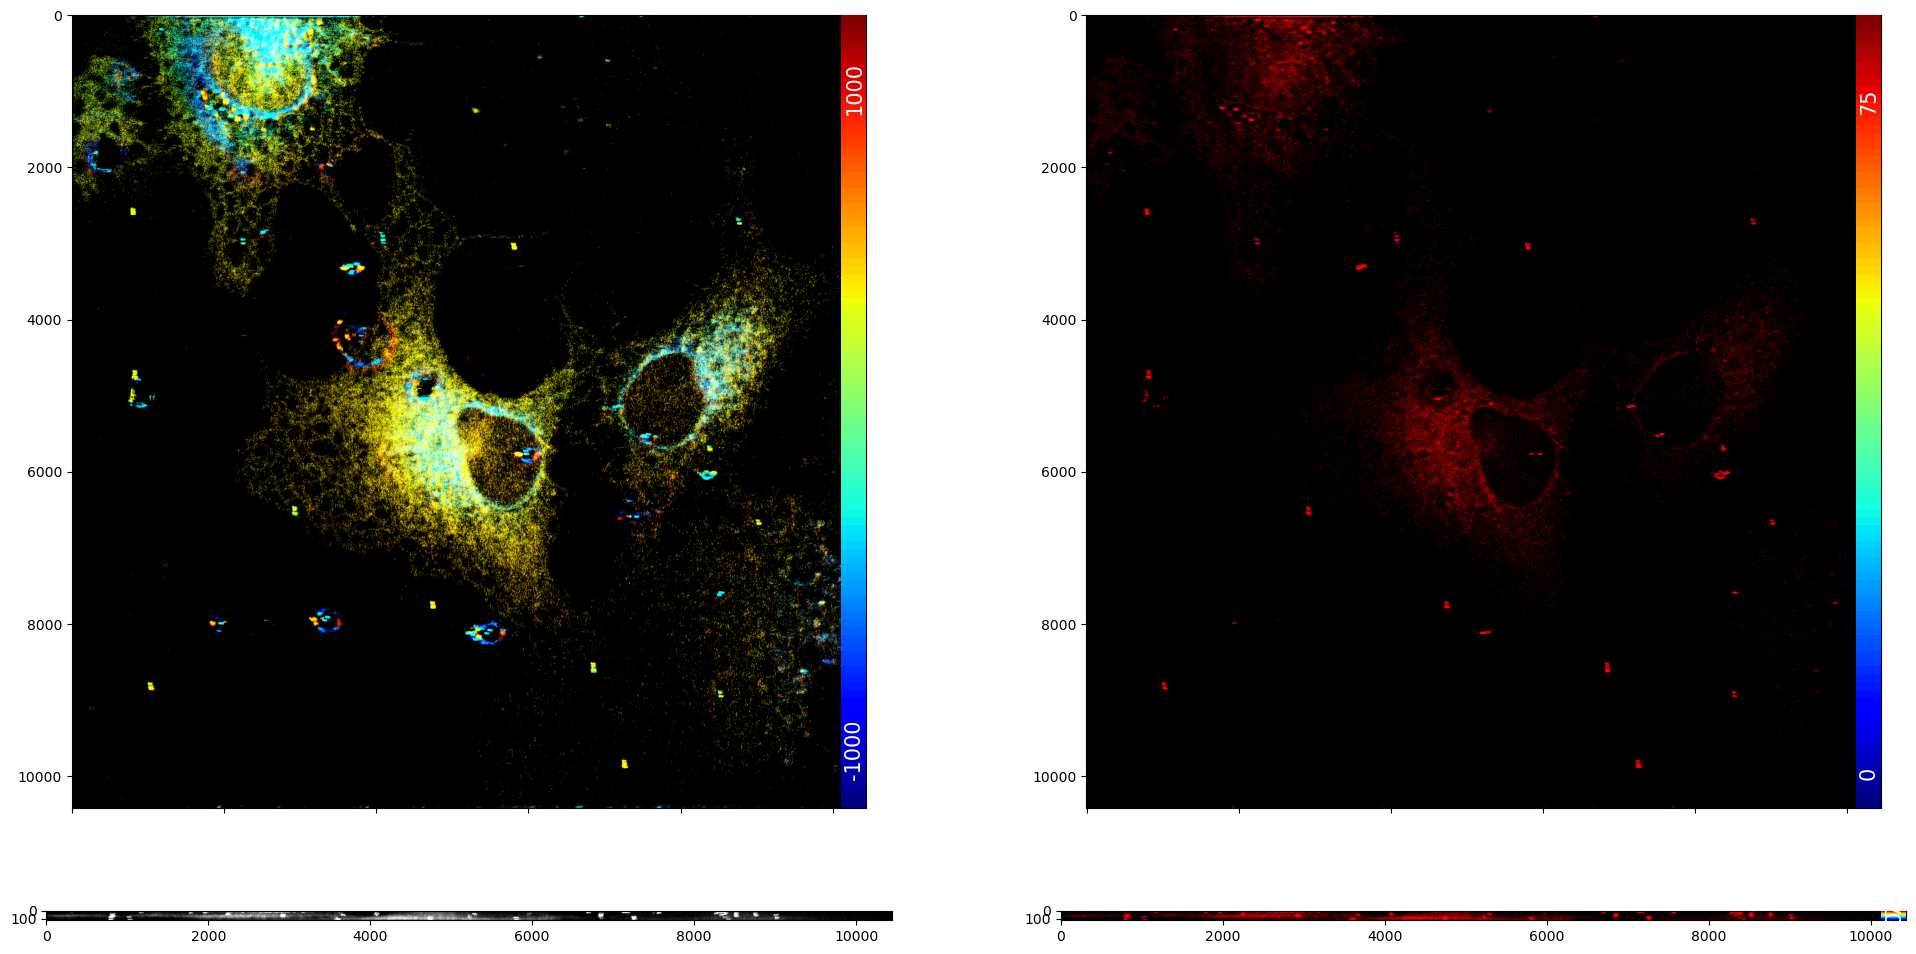

In [13]:
fig = render_emitters(emitters)

In [15]:
ax = fig.axes[0]
img = ax.images[0].get_array()

print(img.dtype, img.shape)

float64 (10417, 10441, 3)


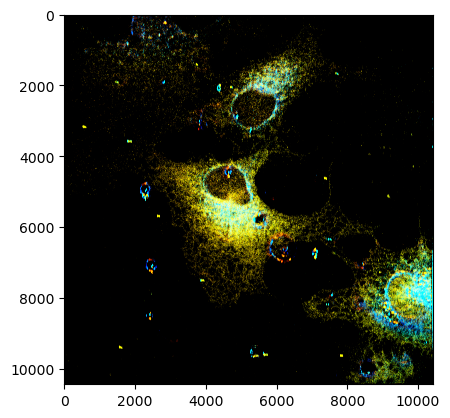

In [16]:
import matplotlib.pyplot as plt
imgt = np.transpose(img, (1, 0, 2))
imgt = imgt[::-1, ::-1, :]
plt.imshow(imgt, cmap='gray')

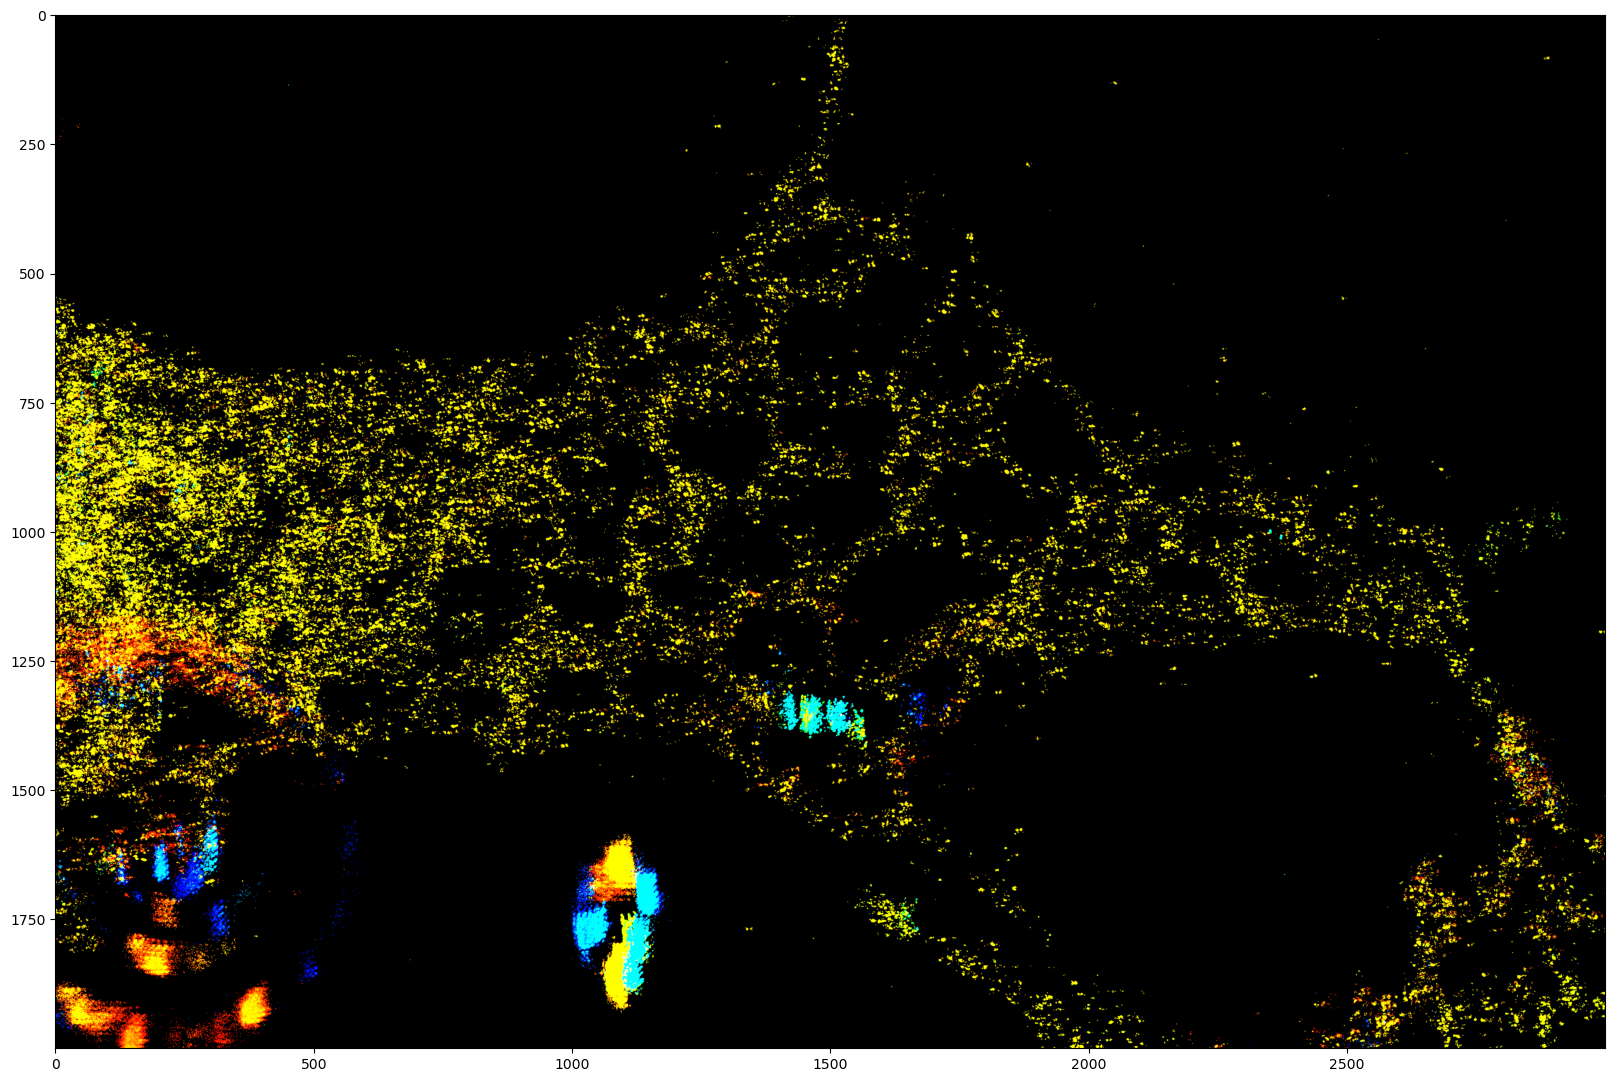

In [18]:
imgt_cropped = imgt[5000:7000, 6000:9000, :]
plt.figure(figsize=(20, 20))
plt.imshow(imgt_cropped, cmap='gray')

In [23]:
import napari
viewer = napari.Viewer()
viewer.add_image(imgt, name='rendered emitters') 

<Image layer 'rendered emitters' at 0x23423937490>

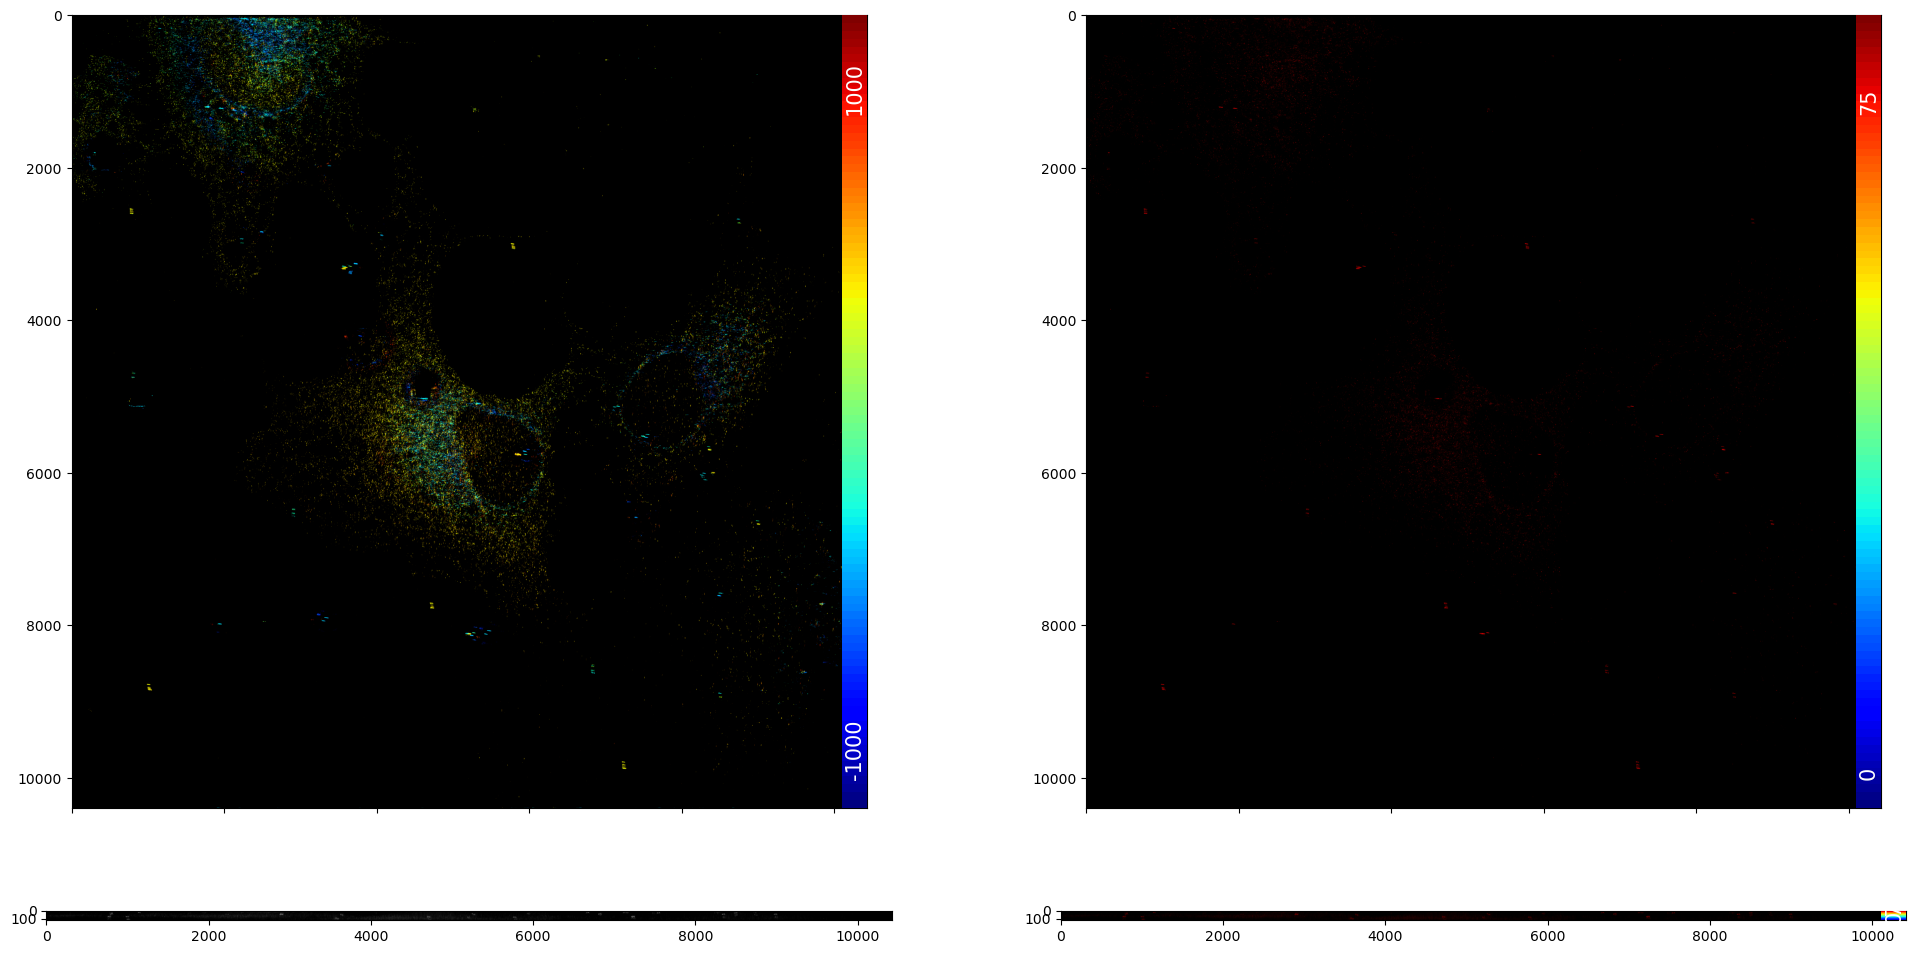

In [ ]:
fig = render_emitters(emitters)

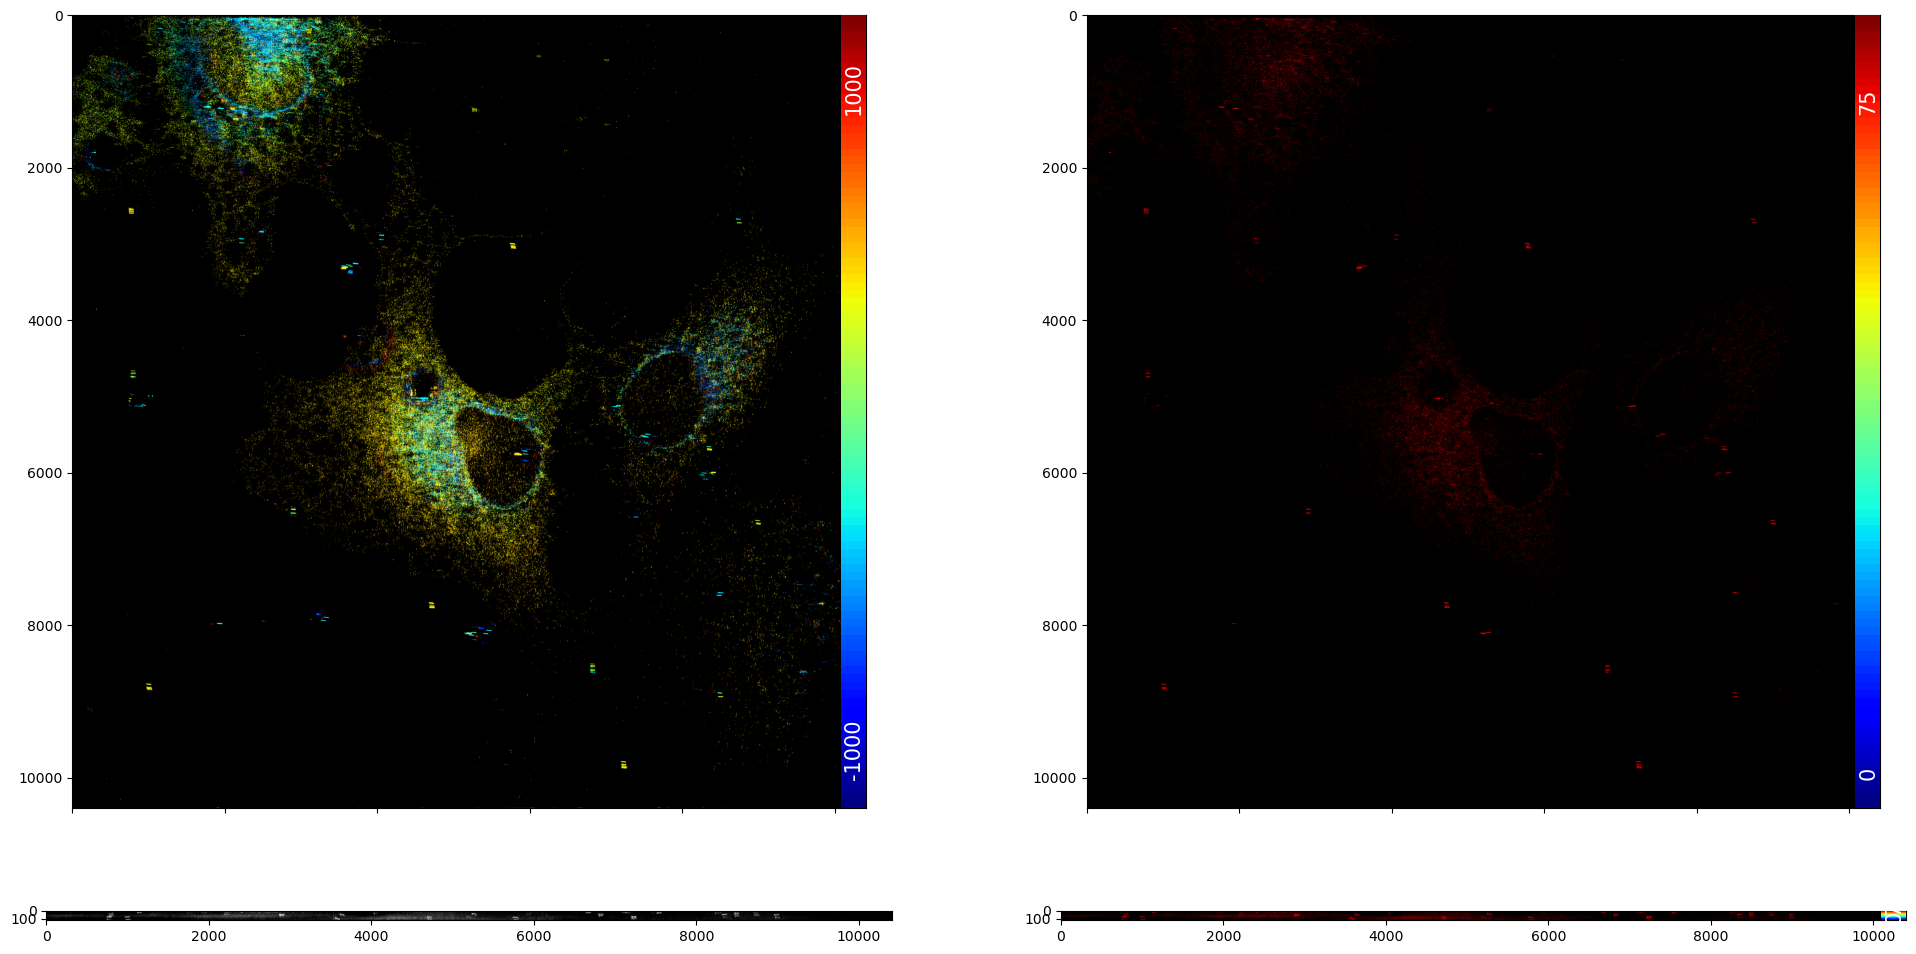

In [ ]:
fig = render_emitters(emitters)

In [ ]:
decode_emitters = emitters

extents = {
    'xextent': [0, 800*decode_emitters.px_size[0]],
    'yextent': [0, 800*decode_emitters.px_size[1]],
    'zextent': [-1000, 1000],
    'colextent': [-1000, 1000]
}

renderer = decode.renderer.Renderer2D(px_size=10., sigma_blur=5, rel_clip=None, abs_clip=50, 
                           **extents, plot_axis=(0, 1),
                           contrast=5)

renderer = decode.renderer.Renderer2D(px_size=10., sigma_blur=5., rel_clip=None, abs_clip=5,
                        **extents, plot_axis=(0, 1),
                        contrast=15.25)

In [12]:
import numpy as np

def render_numpy(emitter):
    rendered = renderer.forward(emitter, emitter.xyz_nm[:, 2])
    rendered = rendered.numpy()
    rendered = np.transpose(rendered, (1, 0, 2))
    return rendered



In [13]:
rendered_decode = render_numpy(decode_emitters)

In [10]:
import napari
viewer = napari.Viewer()
viewer.add_image(rendered_decode, name='decode_rendered') 

<Image layer 'decode_rendered' at 0x1c4d6938a30>

In [14]:

viewer.add_image(rendered_decode, name='decode_rendered') 

<Image layer 'decode_rendered [1]' at 0x1c4d692c0a0>

In [15]:
rendered_decode.shape

(10400, 10400, 3)